# Daisyworld: динамика числа маргариток

Построим график изменения числа чёрных и белых маргариток в
зависимости от модельного времени.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
using Agents
using DataFrames
using CairoMakie

include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## Сбор данных

Функции `black` и `white` проверяют вид маргаритки. На каждом шаге
считаем, сколько агентов каждого вида.

In [2]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.black, count)
 (Main.white, count)

## Запуск модели

Солнечная постоянная равна 1.0 и не меняется. Выполняем 1000 шагов.

In [3]:
model = daisyworld(; solar_luminosity = 1.0)

agent_df, model_df = run!(model, 1000; adata)
first(agent_df, 5)

Row,time,count_black,count_white
,Int64,Int64,Int64
1,0,180,180
2,1,406,167
3,2,569,223
4,3,600,271
5,4,600,287


## Построение графика

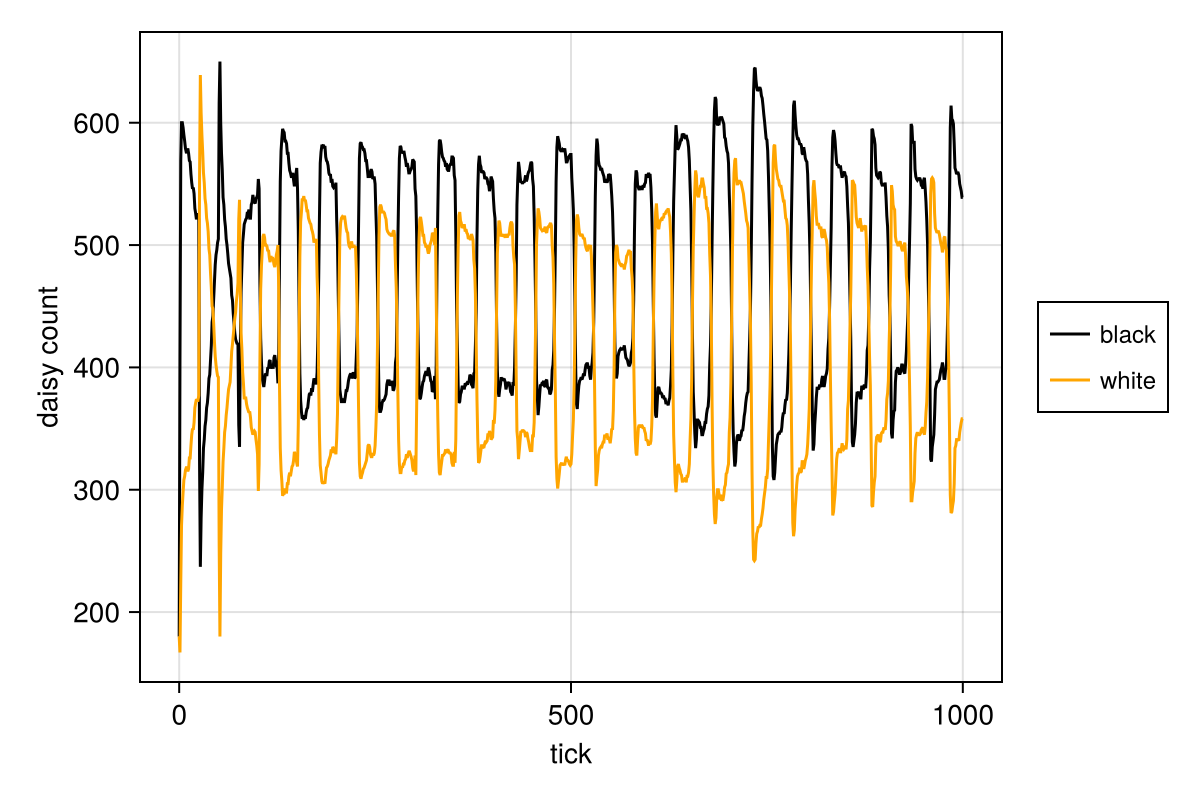

In [4]:
figure = Figure(size = (600, 400));
ax = figure[1, 1] = Axis(figure, xlabel = "tick", ylabel = "daisy count")
blackl = lines!(ax, agent_df[!, :time], agent_df[!, :count_black], color = :black)
whitel = lines!(ax, agent_df[!, :time], agent_df[!, :count_white], color = :orange)
Legend(figure[1, 2], [blackl, whitel], ["black", "white"], labelsize = 12)
figure

## Сохранение графика

In [5]:
save(plotsdir("daisy_count.png"), figure)